<a href="https://colab.research.google.com/github/akshat-646/finance/blob/main/Stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas numpy scikit-learn matplotlib tensorflow -q

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
from datetime import datetime, timedelta
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

In [3]:
TICKERS = {
    "National Alum": "NATIONALUM.NS",
    "Adani Green": "ADANIGREEN.NS",
    "Devyani": "DEVYANI.NS",
    "Coal India": "COALINDIA.NS",
    "Adani Wilmar": "AWL.NS",
    "Rel Power": "RPOWER.NS",
    "SW Solar": "SWSOLAR.NS",
    "Adani Power": "ADANIPOWER.NS",
    "Jio Fin": "JIOFIN.NS",
    "Central Bank": "CENTRALBK.NS",
    "Bharti Airtel": "BHARTIARTL.NS",
    "Brookfield REIT": "BIRET.NS"
}

In [4]:
def fetch_stock_data(ticker, company_name, days=1000):
    """Fetch historical stock data"""
    print(f"Fetching data for {company_name} ({ticker})...")
    try:
        stock = yf.Ticker(ticker)
        end_date = datetime.now()
        start_date = end_date - timedelta(days=days)
        data = stock.history(start=start_date, end=end_date)

        if data.empty:
            print(f"  - No data found for {company_name}")
            return None

        data = data[['Close']].reset_index()
        return data
    except Exception as e:
        print(f"  - Error fetching {company_name}: {e}")
        return None

def prepare_data(data, lookback=60):
    """Prepare data for LSTM (create sequences)"""
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data[['Close']])

    X, y = [], []
    for i in range(lookback, len(scaled_data)):
        X.append(scaled_data[i-lookback:i, 0])
        y.append(scaled_data[i, 0])

    X, y = np.array(X), np.array(y)

    # Split into train (80%) and test (20%)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Reshape for LSTM [samples, timesteps, features]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    return X_train, y_train, X_test, y_test, scaler, data

In [5]:
def build_lstm_model(lookback):
    """Build LSTM model"""
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(lookback, 1), return_sequences=True),
        Dropout(0.2),
        LSTM(50, activation='relu', return_sequences=False),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_lstm_model(model, X_train, y_train, X_test, y_test, epochs=50, batch_size=32):
    """Train LSTM model"""
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    return history


In [6]:
def evaluate_model(model, X_test, y_test, scaler):
    """Evaluate model performance"""
    y_pred = model.predict(X_test, verbose=0)

    # Inverse transform predictions
    y_pred_actual = scaler.inverse_transform(y_pred)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)

    print(f"\n--- Model Evaluation ---")
    print(f"RMSE: ₹{rmse:.2f}")
    print(f"MAE: ₹{mae:.2f}")
    print(f"R² Score: {r2:.4f}")

    return rmse, mae, r2, y_pred_actual, y_test_actual

def predict_future(model, data, scaler, lookback, days=30):
    """Predict future stock prices"""
    last_sequence = scaler.transform(data[['Close']].tail(lookback).values)
    predictions = []

    for _ in range(days):
        input_seq = last_sequence[-lookback:].reshape(1, lookback, 1)
        next_pred = model.predict(input_seq, verbose=0)[0, 0]
        predictions.append(next_pred)
        last_sequence = np.append(last_sequence, next_pred)

    # Inverse transform predictions
    predictions = np.array(predictions).reshape(-1, 1)
    future_prices = scaler.inverse_transform(predictions)

    return future_prices.flatten()

In [7]:
def plot_results(data, y_test_actual, y_pred_actual, future_prices, company_name, lookback):
    """Plot actual vs predicted prices and future predictions"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

    # Plot 1: Historical data and predictions
    # Calculate actual indices correctly
    total_sequences = len(data) - lookback
    train_sequences = int(total_sequences * 0.8)
    test_start_idx = train_sequences + lookback
    test_end_idx = test_start_idx + len(y_test_actual)

    ax1.plot(data['Date'][:test_start_idx], data['Close'][:test_start_idx],
             label='Training Data', color='blue', linewidth=1)
    test_dates = data['Date'][test_start_idx:test_end_idx]
    ax1.plot(test_dates, y_test_actual, label='Actual Test Data', color='green', linewidth=2)
    ax1.plot(test_dates, y_pred_actual, label='LSTM Predictions', color='red', linewidth=2, linestyle='--')
    ax1.set_title(f'{company_name} - Historical vs Predicted Prices', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price (₹)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)


    # Plot 2: Future predictions
    last_date = data['Date'].iloc[-1]
    future_dates = [last_date + timedelta(days=i) for i in range(1, len(future_prices) + 1)]
    ax2.plot(data['Date'].tail(60), data['Close'].tail(60),
             label='Recent Historical Data (60 days)', color='blue', linewidth=1)
    ax2.plot(future_dates, future_prices, label='Future Predictions (30 days)',
             color='orange', linewidth=2, linestyle='--', marker='o', markersize=4)
    ax2.set_title(f'{company_name} - 30-Day Future Price Prediction', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Price (₹)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.savefig(f'/content/{company_name}_lstm_prediction.png', dpi=100, bbox_inches='tight')
    print(f"✓ Plot saved as '{company_name}_lstm_prediction.png'")
    plt.show()

In [8]:
def save_predictions(company_name, y_pred_actual, y_test_actual, future_prices):
    """Save predictions to CSV in Colab"""
    output_folder = "/content/lstm_predictions"
    os.makedirs(output_folder, exist_ok=True)

    # Save test predictions
    test_df = pd.DataFrame({
        'Actual': y_test_actual.flatten(),
        'Predicted': y_pred_actual.flatten(),
        'Error': (y_pred_actual.flatten() - y_test_actual.flatten())
    })
    test_df.to_csv(f"{output_folder}/{company_name}_test_predictions.csv", index=False)

    # Save future predictions
    future_dates = [datetime.now() + timedelta(days=i) for i in range(1, len(future_prices) + 1)]
    future_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Price': future_prices
    })
    future_df.to_csv(f"{output_folder}/{company_name}_future_predictions.csv", index=False)
    print(f"✓ Predictions saved to '/content/lstm_predictions/'")

def select_companies():
    """Let user select which companies to predict"""
    print("\n" + "=" * 60)
    print("Available Companies:")
    print("=" * 60)

    companies_list = list(TICKERS.items())
    for idx, (company, ticker) in enumerate(companies_list, 1):
        print(f"{idx}. {company} ({ticker})")

    print(f"{len(companies_list) + 1}. All Companies")
    print(f"{len(companies_list) + 2}. Exit")

    while True:
        try:
            choice = input("\nEnter your choice (number): ").strip()
            choice = int(choice)

            if choice == len(companies_list) + 1:
                # Select all
                return dict(companies_list)
            elif choice == len(companies_list) + 2:
                # Exit
                print("Exiting...")
                return None
            elif 1 <= choice <= len(companies_list):
                # Select single company
                selected = companies_list[choice - 1]
                return {selected[0]: selected[1]}
            else:
                print(f"Invalid choice. Please enter 1-{len(companies_list) + 2}")
        except ValueError:
            print("Invalid input. Please enter a number.")


In [9]:
def main():
  while True:
    print("=" * 60)
    print("LSTM Stock Price Prediction for Indian Markets")
    print("=" * 60)

    # Let user select companies
    selected_tickers = select_companies()
    if selected_tickers is None:
        return

    print(f"\n✓ Selected {len(selected_tickers)} company/companies for prediction")

    lookback = 60  # Use 60 days of history
    prediction_days = 30  # Predict 30 days into future

    all_results = []

    for company, ticker in selected_tickers.items():
        print(f"\n{'='*60}")
        print(f"Processing: {company}")
        print(f"{'='*60}")

        # Fetch data
        data = fetch_stock_data(ticker, company)
        if data is None:
            continue

        print(f"Data points fetched: {len(data)}")
        print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")

        # Prepare data
        X_train, y_train, X_test, y_test, scaler, data = prepare_data(data, lookback)
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

        # Build and train model
        print("\nBuilding LSTM model...")
        model = build_lstm_model(lookback)
        print(model.summary())

        print("\nTraining model...")
        history = train_lstm_model(model, X_train, y_train, X_test, y_test, epochs=50)

        # Evaluate
        rmse, mae, r2, y_pred_actual, y_test_actual = evaluate_model(model, X_test, y_test, scaler)

        # Future predictions
        print(f"\nPredicting next {prediction_days} days...")
        future_prices = predict_future(model, data, scaler, lookback, prediction_days)

        print(f"\n--- Next 30-Day Price Predictions for {company} ---")
        for i, price in enumerate(future_prices[:10], 1):
            print(f"  Day {i:2d}: ₹{price:8.2f}")
        if len(future_prices) > 10:
            print(f"  ... (showing first 10 of {len(future_prices)})")

        # Plot and save
        plot_results(data, y_test_actual, y_pred_actual, future_prices, company, lookback)
        save_predictions(company, y_pred_actual, y_test_actual, future_prices)

        all_results.append({
            'Company': company,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'Latest_Price': data['Close'].iloc[-1],
            'Predicted_30d': future_prices[-1]
        })

    # Summary
    print(f"\n{'='*60}")
    print("SUMMARY OF ALL PREDICTIONS")
    print(f"{'='*60}")
    summary_df = pd.DataFrame(all_results)
    print(summary_df.to_string(index=False))

    print("\n✓ All files saved to /content/lstm_predictions/")
    print("✓ You can download them using the file browser on the left side")

LSTM Stock Price Prediction for Indian Markets

Available Companies:
1. National Alum (NATIONALUM.NS)
2. Adani Green (ADANIGREEN.NS)
3. Devyani (DEVYANI.NS)
4. Coal India (COALINDIA.NS)
5. Adani Wilmar (AWL.NS)
6. Rel Power (RPOWER.NS)
7. SW Solar (SWSOLAR.NS)
8. Adani Power (ADANIPOWER.NS)
9. Jio Fin (JIOFIN.NS)
10. Central Bank (CENTRALBK.NS)
11. Bharti Airtel (BHARTIARTL.NS)
12. Brookfield REIT (BIRET.NS)
13. All Companies
14. Exit

Enter your choice (number): 2

✓ Selected 1 company/companies for prediction

Processing: Adani Green
Fetching data for Adani Green (ADANIGREEN.NS)...
Data points fetched: 674
Date range: 2023-02-01 00:00:00+05:30 to 2025-10-27 00:00:00+05:30
Training samples: 491, Test samples: 123

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

None

Training model...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.3478 - mae: 0.5275 - val_loss: 0.0146 - val_mae: 0.1175
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0676 - mae: 0.1989 - val_loss: 8.0711e-04 - val_mae: 0.0213
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0331 - mae: 0.1383 - val_loss: 0.0117 - val_mae: 0.1051
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0174 - mae: 0.1089 - val_loss: 0.0057 - val_mae: 0.0719
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0126 - mae: 0.0917 - val_loss: 8.0871e-04 - val_mae: 0.0212
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0098 - mae: 0.0696 - val_loss: 6.2669e-04 - val_mae: 0.0183
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0127 - mae: 0.0773 - val_loss: 6.0597e-04 - val_mae: 0.0179
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0089 - mae: 0.0655 - val_loss: 7.4572e-04 - val_mae: 0.0204
Epoch 9/50
16/16 ━━

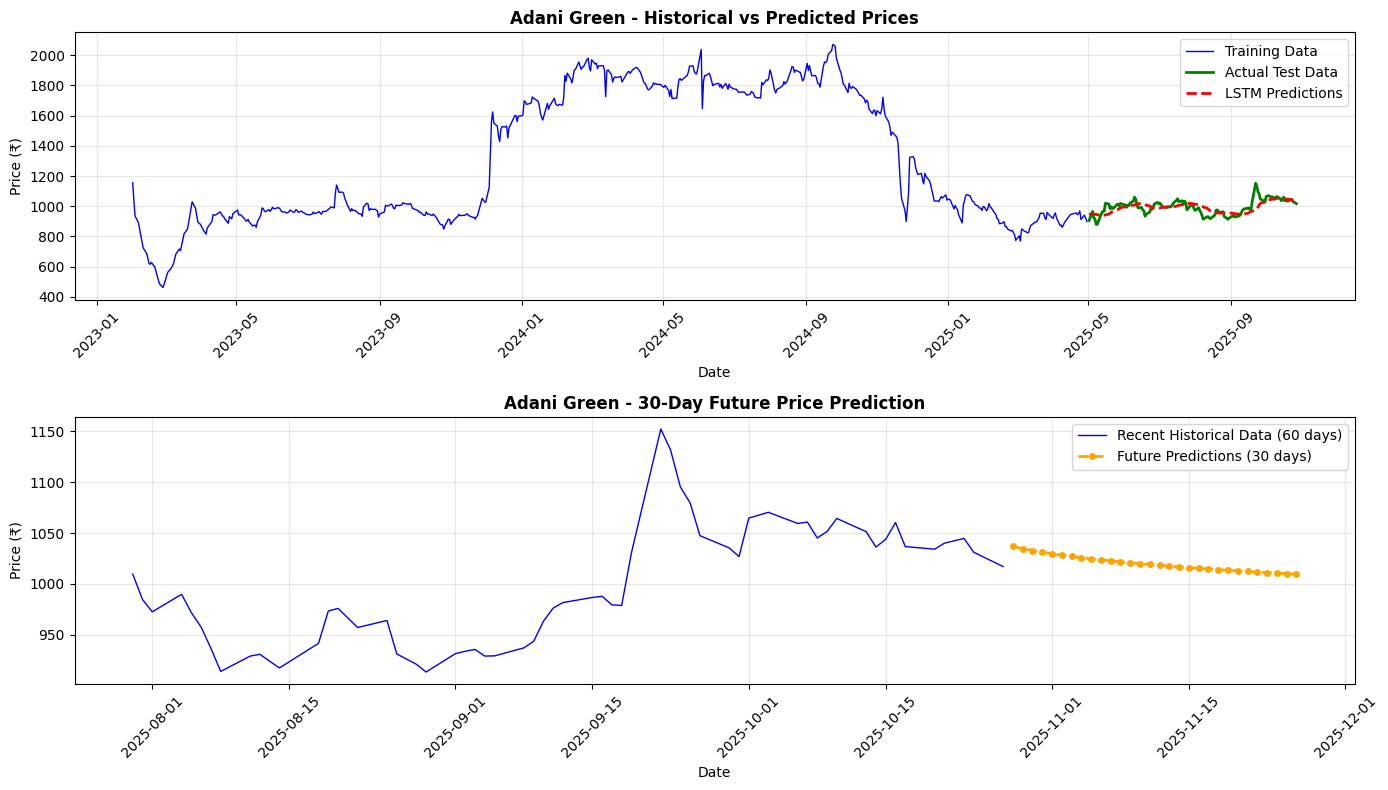

✓ Predictions saved to '/content/lstm_predictions/'

SUMMARY OF ALL PREDICTIONS
    Company      RMSE       MAE       R2  Latest_Price  Predicted_30d
Adani Green 38.805008 28.077951 0.363167   1017.099976    1009.674683

✓ All files saved to /content/lstm_predictions/
✓ You can download them using the file browser on the left side
LSTM Stock Price Prediction for Indian Markets

Available Companies:
1. National Alum (NATIONALUM.NS)
2. Adani Green (ADANIGREEN.NS)
3. Devyani (DEVYANI.NS)
4. Coal India (COALINDIA.NS)
5. Adani Wilmar (AWL.NS)
6. Rel Power (RPOWER.NS)
7. SW Solar (SWSOLAR.NS)
8. Adani Power (ADANIPOWER.NS)
9. Jio Fin (JIOFIN.NS)
10. Central Bank (CENTRALBK.NS)
11. Bharti Airtel (BHARTIARTL.NS)
12. Brookfield REIT (BIRET.NS)
13. All Companies
14. Exit

Enter your choice (number): 14
Exiting...


In [10]:
if __name__ == "__main__":
    main()